In [1]:
# ── Mount Google Drive & add project root to sys.path ──
from google.colab import drive
drive.mount("/content/drive")

import os, sys
PROJECT_ROOT = "/content/drive/MyDrive/690AB/flash-attention"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "pallas_attn")
os.makedirs(RESULTS_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
# Reusable analysis / timing / plotting utilities live in utils/.
from utils.timing import safe_time_jax
from utils.roofline import (
    ridge_point,
    throughput,
    attn_fwd_flops,
    attn_bwd_flops,
    naive_fwd_bytes,
    naive_bwd_bytes,
    flash_fwd_bytes,
    flash_bwd_bytes,
    A100_PEAK_TFLOPS,
    A100_PEAK_BW_GBS,
)
from utils.plotting import plot_roofline_dual_pass, plot_dual_pass_lines

# Keep old callsites working with minimal notebook edits.
safe_time = safe_time_jax
thru = throughput

In [3]:
!git clone -b pallas_fa https://github.com/MasterSkepticista/gpt2.git

Cloning into 'gpt2'...
remote: Enumerating objects: 226, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 226 (delta 131), reused 176 (delta 81), pack-reused 0 (from 0)
Receiving objects: 100% (226/226), 66.21 KiB | 16.55 MiB/s, done.
Resolving deltas: 100% (131/131), done.


In [4]:
%cd /content/gpt2

/content/gpt2


In [5]:
!pip install -q -r requirements.txt && pip install -q -U flax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.1/525.1 kB 34.5 MB/s eta 0:00:00


In [6]:
# Use the GPU instead.
!sed -i 's/interpret=True/interpret=False/g' attention.py

In [7]:
# Known issue: Causal backward mismatches due to precision error.
!python benchmark.py

I0430 21:27:48.019700 140486080131712 xla_bridge.py:822] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
Forward pass result match: True
Reference shapes: (1, 1024, 12, 64) (1, 1024, 12, 64) (1, 1024, 12, 64)
Flash shapes: (1, 1024, 12, 64) (1, 1024, 12, 64) (1, 1024, 12, 64)
Backward pass dQ match: False
Backward pass dK match: False
Backward pass dV match: False


In [ ]:
# Modified to download small 10k tokens dataset instead of 10b
!python fineweb.py --outdir ./data

2026-04-29 02:09:40.275065: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 02:09:40.345753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
README.md: 26.4kB [00:00, 49.0MB/s]
Resolving data files: 100% 2410/2410 [00:00<00:00, 79961.02it/s]
Shard 000: 1000it [00:01, 532.98it/s]
Shard 001: 1000it [00:01, 564.69it/s]
Shard 002: 1000it [00:01, 561.32it/s]
Shard 003: 1000it [00:01, 524.43it/s]
Shard 004: 1000it [00:01, 505.76it/s]
Shard 005: 1000it [00:01, 559.00it/s]
Shard 006: 1000it [00:01, 559.64it/s]
Shard 0

In [ ]:
# SDPA Implementation options:
# xla: naive full softmax attention, this should be slowest
# cudnn: jax built-in SDPA, which internally calls cuDNN flash attention kernel
# pallas: custom pallas flash attention kernel.
!XLA_PYTHON_CLIENT_MEM_FRACTION=0.9 python train.py \
--workdir artifacts/gpt2_124M \
--config configs/default.py \
--config.total_steps 499 \
--config.batch_size 64 \
--config.grad_accum_steps 8 \
--config.model.block_size 2048 \
--config.log_train_steps 5 \
--config.model.sdpa_implementation cudnn

I0429 02:45:36.979895 136772141478528 xla_bridge.py:822] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
I0429 02:45:37.119359 136772141478528 train.py:142] Hello from process 0 holding 1 device(s)
I0429 02:45:37.119507 136772141478528 train.py:147] NOTE: Total devices: 1
I0429 02:45:39.437203 136772141478528 train.py:147] NOTE: +-----------------------+---------------+---------+------------+-----------+---------+
| Name                  | Shape         | Dtype   | Size       | Mean      | Std     |
+-----------------------+---------------+---------+------------+-----------+---------+
| 0/attn/c_attn/bias    | (2304,)       | float32 | 2,304      | 0.0       | 0.0     |
| 0/attn/c_attn/kernel  | (768, 2304)   | float32 | 1,769,472  | -6.98e-07 | 0.02    |
| 0/attn/c_proj/bias    | (768,)        | float32 | 768        | 0.0       | 0.0     |
| 0/attn/c_proj/kernel  | (12, 64, 768) | float32 | 58

## Training speed (gpt2-124M, T=2048, `bs=64@accum4`, `A100 GPU`)

Method: `tok/s = tokens_per_batch * steps_per_sec`

`pallas`: ~29k tok/s

`cudnn`: ~35k tok/s

`xla`: ~18k tok/s

## Kernel-Level Roofline Analysis (Naive vs. Pallas Flash)

Everything above this point trains the **full GPT-2 124M model** end-to-end and reports throughput (`tok/s`). That's a system-level benchmark — it can't tell us *why* one attention backend is faster than another.

This section steps **down a level** and benchmarks just the attention kernel directly, the same way the parent project (`690AB_sem_project.ipynb`) does for the Triton implementation. We sweep over sequence length $T$ and head dimension $C$ and compare:

- **Naive attention** (`naive_attention` in `attention.py`) — XLA-compiled standard SDPA, materializes the full $T\times T$ score matrix in HBM.
- **Flash attention** (`flash_attention` in `attention.py`) — the custom Pallas kernel using tiled online softmax (FA-2 style: outer loop over Q tiles, inner over K/V tiles).

For each shape we report:
1. **FLOP count** (forward / backward)
2. **HBM byte traffic** (forward / backward, theoretical IO model)
3. **Arithmetic intensity** = FLOPs / bytes
4. **Roofline plot** for A100 (paper-aligned ceilings)

### Conventions
- All measurements use `bfloat16` (matches GPT-2 124M training config).
- Causal masking is **on** (matches the trained model). Note: the kernel applies the mask but does not skip upper-triangle blocks, so wallclock cost is the same as `causal=False`. We report *algorithmic* FLOPs (×0.5 for causal).
- $B*H$ is the fused batch dimension in this implementation, so `num_heads` and `batch_size` only scale total work; they don't affect arithmetic intensity. We pin $B=1, H=12$ (GPT-2 124M) so the GPU has enough work to hide launch overhead.

In [8]:
import sys, gc
sys.path.insert(0, "/content/gpt2")

import jax
import jax.numpy as jnp
import pandas as pd

from attention import naive_attention, flash_attention

print("JAX devices       :", jax.devices())
print("Default backend   :", jax.default_backend())
assert jax.default_backend() == "gpu", "Need GPU runtime — use an A100 (or other GPU) in Colab / your cloud runtime."

A100_RIDGE = ridge_point(A100_PEAK_TFLOPS, A100_PEAK_BW_GBS)

print(f"A100 roof (dense BF16): {A100_PEAK_TFLOPS:>5.0f} TFLOP/s  |  {A100_PEAK_BW_GBS:>5.0f} GB/s  |  ridge ≈ {A100_RIDGE:>4.0f} FLOPs/byte")

JAX devices       : [CudaDevice(id=0)]
Default backend   : gpu
L4 roof (dense BF16):   121 TFLOP/s  |    300 GB/s  |  ridge ≈  403 FLOPs/byte


In [9]:
# Reused from utils.roofline:
# - attn_fwd_flops / attn_bwd_flops
# - naive_fwd_bytes / naive_bwd_bytes
# - flash_fwd_bytes / flash_bwd_bytes
T, C, B, H = 2048, 64, 1, 12
print(f"Sanity check at GPT-2 124M training shape (B={B}, T={T}, H={H}, C={C}, causal=True):\n")
print(f"  forward FLOPs       : {attn_fwd_flops(T,C)*B*H/1e9:>7.1f} GFLOPs")
print(f"  backward FLOPs      : {attn_bwd_flops(T,C)*B*H/1e9:>7.1f} GFLOPs")
print(f"  Naive forward bytes : {naive_fwd_bytes(T,C)*B*H/1e6:>7.1f} MB")
print(f"  Flash forward bytes : {flash_fwd_bytes(T,C)*B*H/1e6:>7.1f} MB")
print(f"  Naive AI (fwd)      : {(attn_fwd_flops(T,C)) / naive_fwd_bytes(T,C):>7.1f} FLOPs/byte")
print(f"  Flash AI (fwd)      : {(attn_fwd_flops(T,C)) / flash_fwd_bytes(T,C):>7.1f} FLOPs/byte")
print(f"  A100 ridge          : {A100_RIDGE:>7.0f} FLOPs/byte  →  Naive is memory-bound, Flash crosses ridge as T grows")

Sanity check at GPT-2 124M training shape (B=1, T=2048, H=12, C=64, causal=True):

  forward FLOPs       :     6.4 GFLOPs
  backward FLOPs      :    16.1 GFLOPs
  Naive forward bytes :   415.2 MB
  Flash forward bytes :    12.7 MB
  Naive AI (fwd)      :    15.5 FLOPs/byte
  Flash AI (fwd)      :   508.0 FLOPs/byte
  L4 ridge            :     403 FLOPs/byte  →  Naive is memory-bound, Flash crosses ridge as T grows


In [10]:
@jax.jit
def naive_fwd_jit(q, k, v):
    return naive_attention(q, k, v, causal=True)

@jax.jit
def flash_fwd_jit(q, k, v):
    return flash_attention(q, k, v, causal=True)

@jax.jit
def naive_grad_jit(q, k, v, do):
    """Sum-of-output loss → grads w.r.t. (q, k, v). Equivalent to passing dO=do."""
    def loss(q_, k_, v_):
        return jnp.sum(naive_attention(q_, k_, v_, causal=True) * do)
    return jax.grad(loss, argnums=(0, 1, 2))(q, k, v)

@jax.jit
def flash_grad_jit(q, k, v, do):
    def loss(q_, k_, v_):
        return jnp.sum(flash_attention(q_, k_, v_, causal=True) * do)
    return jax.grad(loss, argnums=(0, 1, 2))(q, k, v)

# Timing via safe_time_jax (aliased as safe_time in the import cell)

In [11]:
B, H = 1, 12
Ts = [512, 1024, 2048, 4096, 8192]
Cs = [32, 64, 128]
DTYPE = jnp.bfloat16

# throughput helper comes from utils.roofline (aliased as `thru` in import cell)

results = []
for T in Ts:
    for C in Cs:
        print(f"T={T:>5d}  C={C:>3d}  ", end="", flush=True)
        keys = jax.random.split(jax.random.key(42 + T*1000 + C), 4)
        q  = jax.random.normal(keys[0], (B, T, H, C), DTYPE)
        k  = jax.random.normal(keys[1], (B, T, H, C), DTYPE)
        v  = jax.random.normal(keys[2], (B, T, H, C), DTYPE)
        do = jax.random.normal(keys[3], (B, T, H, C), DTYPE)

        t_flash_fwd = safe_time(flash_fwd_jit,  (q, k, v))
        t_naive_fwd = safe_time(naive_fwd_jit,  (q, k, v))
        t_flash_bwd = safe_time(flash_grad_jit, (q, k, v, do))
        t_naive_bwd = safe_time(naive_grad_jit, (q, k, v, do))

        bs_flat = B * H
        F_fwd = attn_fwd_flops(T, C) * bs_flat
        F_bwd = attn_bwd_flops(T, C) * bs_flat
        Bn_f  = naive_fwd_bytes(T, C) * bs_flat
        Bn_b  = naive_bwd_bytes(T, C) * bs_flat
        Bf_f  = flash_fwd_bytes(T, C) * bs_flat
        Bf_b  = flash_bwd_bytes(T, C) * bs_flat

        results.append(dict(
            T=T, C=C, B=B, H=H,
            naive_fwd_ms     = t_naive_fwd * 1e3,
            flash_fwd_ms     = t_flash_fwd * 1e3,
            naive_bwd_ms     = t_naive_bwd * 1e3,
            flash_bwd_ms     = t_flash_bwd * 1e3,
            fwd_GFLOPs       = F_fwd / 1e9,
            bwd_GFLOPs       = F_bwd / 1e9,
            naive_fwd_MB     = Bn_f / 1e6,
            flash_fwd_MB     = Bf_f / 1e6,
            naive_bwd_MB     = Bn_b / 1e6,
            flash_bwd_MB     = Bf_b / 1e6,
            AI_naive_fwd     = F_fwd / Bn_f,
            AI_flash_fwd     = F_fwd / Bf_f,
            AI_naive_bwd     = F_bwd / Bn_b,
            AI_flash_bwd     = F_bwd / Bf_b,
            naive_fwd_TFLOPS = thru(t_naive_fwd, F_fwd) / 1e12,
            flash_fwd_TFLOPS = thru(t_flash_fwd, F_fwd) / 1e12,
            naive_bwd_TFLOPS = thru(t_naive_bwd, F_bwd) / 1e12,
            flash_bwd_TFLOPS = thru(t_flash_bwd, F_bwd) / 1e12,
            naive_fwd_BW_GBs = thru(t_naive_fwd, Bn_f) / 1e9,
            flash_fwd_BW_GBs = thru(t_flash_fwd, Bf_f) / 1e9,
            naive_bwd_BW_GBs = thru(t_naive_bwd, Bn_b) / 1e9,
            flash_bwd_BW_GBs = thru(t_flash_bwd, Bf_b) / 1e9,
        ))

        del q, k, v, do
        gc.collect()

        def fmt(t):
            return "  oom" if (t != t) else f"{t*1e3:6.2f}ms"

        print(f"  naive_fwd={fmt(t_naive_fwd)}  flash_fwd={fmt(t_flash_fwd)}"
              f"  naive_bwd={fmt(t_naive_bwd)}  flash_bwd={fmt(t_flash_bwd)}")

df = pd.DataFrame(results)
print(f"\nSweep finished — {len(df)} (T, C) points collected.")

T=  512  C= 32    naive_fwd=  0.16ms  flash_fwd=  0.12ms  naive_bwd=  0.22ms  flash_bwd=  0.19ms
T=  512  C= 64    naive_fwd=  0.16ms  flash_fwd=  0.13ms  naive_bwd=  0.25ms  flash_bwd=  0.27ms
T=  512  C=128    naive_fwd=  0.18ms  flash_fwd=  0.21ms  naive_bwd=  0.25ms  flash_bwd=  0.35ms
T= 1024  C= 32    naive_fwd=  0.37ms  flash_fwd=  0.20ms  naive_bwd=  0.85ms  flash_bwd=  0.34ms
T= 1024  C= 64    naive_fwd=  0.38ms  flash_fwd=  0.23ms  naive_bwd=  0.88ms  flash_bwd=  0.45ms
T= 1024  C=128    naive_fwd=  0.39ms  flash_fwd=  0.28ms  naive_bwd=  1.00ms  flash_bwd=  0.83ms
T= 2048  C= 32    naive_fwd=  1.91ms  flash_fwd=  0.27ms  naive_bwd=  4.82ms  flash_bwd=  0.79ms
T= 2048  C= 64    naive_fwd=  1.96ms  flash_fwd=  0.39ms  naive_bwd=  4.86ms  flash_bwd=  1.15ms
T= 2048  C=128    naive_fwd=  2.00ms  flash_fwd=  0.71ms  naive_bwd=  5.11ms  flash_bwd=  2.57ms
T= 4096  C= 32    naive_fwd=  7.14ms  flash_fwd=  0.70ms  naive_bwd= 18.75ms  flash_bwd=  2.51ms
T= 4096  C= 64    naive_fwd=  

In [12]:
timing_cols = [
    "T", "C",
    "naive_fwd_ms", "flash_fwd_ms",
    "naive_bwd_ms", "flash_bwd_ms",
    "naive_fwd_TFLOPS", "flash_fwd_TFLOPS",
    "naive_bwd_TFLOPS", "flash_bwd_TFLOPS",
]
ai_cols = [
    "T", "C",
    "fwd_GFLOPs", "bwd_GFLOPs",
    "naive_fwd_MB", "flash_fwd_MB",
    "AI_naive_fwd", "AI_flash_fwd",
    "AI_naive_bwd", "AI_flash_bwd",
]

print("=== Timing & achieved throughput ===\n")
print(df[timing_cols].round(2).to_string(index=False))

print("\n=== FLOPs / bytes / arithmetic intensity ===\n")
print(df[ai_cols].round(2).to_string(index=False))

print("\n=== Speedup of Flash over Naive (×) ===\n")
spd = df[["T", "C"]].copy()
spd["fwd_speedup"] = (df["naive_fwd_ms"] / df["flash_fwd_ms"]).round(2)
spd["bwd_speedup"] = (df["naive_bwd_ms"] / df["flash_bwd_ms"]).round(2)
spd["AI_fwd_ratio"] = (df["AI_flash_fwd"] / df["AI_naive_fwd"]).round(1)
spd["AI_bwd_ratio"] = (df["AI_flash_bwd"] / df["AI_naive_bwd"]).round(1)
print(spd.to_string(index=False))

=== Timing & achieved throughput ===

   T   C  naive_fwd_ms  flash_fwd_ms  naive_bwd_ms  flash_bwd_ms  naive_fwd_TFLOPS  flash_fwd_TFLOPS  naive_bwd_TFLOPS  flash_bwd_TFLOPS
 512  32          0.16          0.12          0.22          0.19              1.27              1.74              2.28              2.62
 512  64          0.16          0.13          0.25          0.27              2.50              3.16              3.96              3.74
 512 128          0.18          0.21          0.25          0.35              4.45              3.91              7.97              5.71
1024  32          0.37          0.20          0.85          0.34              2.20              4.02              2.38              5.99
1024  64          0.38          0.23          0.88          0.45              4.20              7.11              4.57              8.87
1024 128          0.39          0.28          1.00          0.83              8.31             11.32              8.01              9.75
204

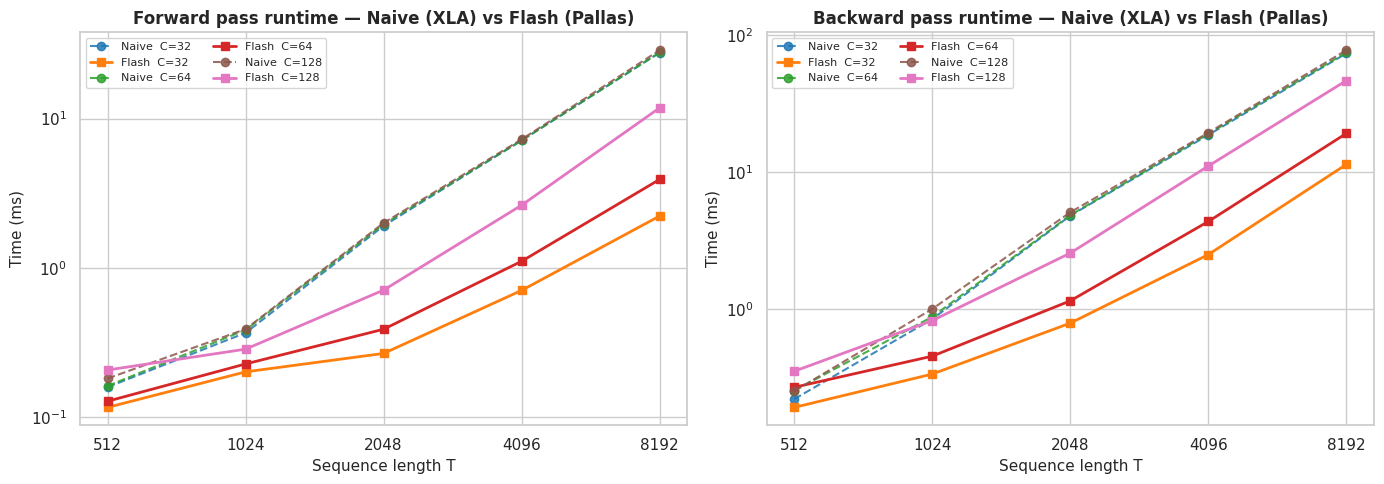

Saved: /content/drive/MyDrive/690AB/flash-attention/results/pallas_attn/pallas_runtime.png


In [13]:
naive_palette = {32: "#1f77b4", 64: "#2ca02c", 128: "#8c564b"}
flash_palette = {32: "#ff7f0e", 64: "#d62728", 128: "#e377c2"}

plot_dual_pass_lines(
    df, seq_col="T", seq_ticks=Ts, configs=Cs, config_col="C",
    naive_col_fmt="naive_{direction}_ms",
    flash_col_fmt="flash_{direction}_ms",
    naive_palette=naive_palette,
    flash_palette=flash_palette,
    ylabel="Time (ms)",
    title_fmt="{direction} pass runtime \u2014 Naive (XLA) vs Flash (Pallas)",
    output_path=os.path.join(RESULTS_DIR, "pallas_runtime.png"),
)

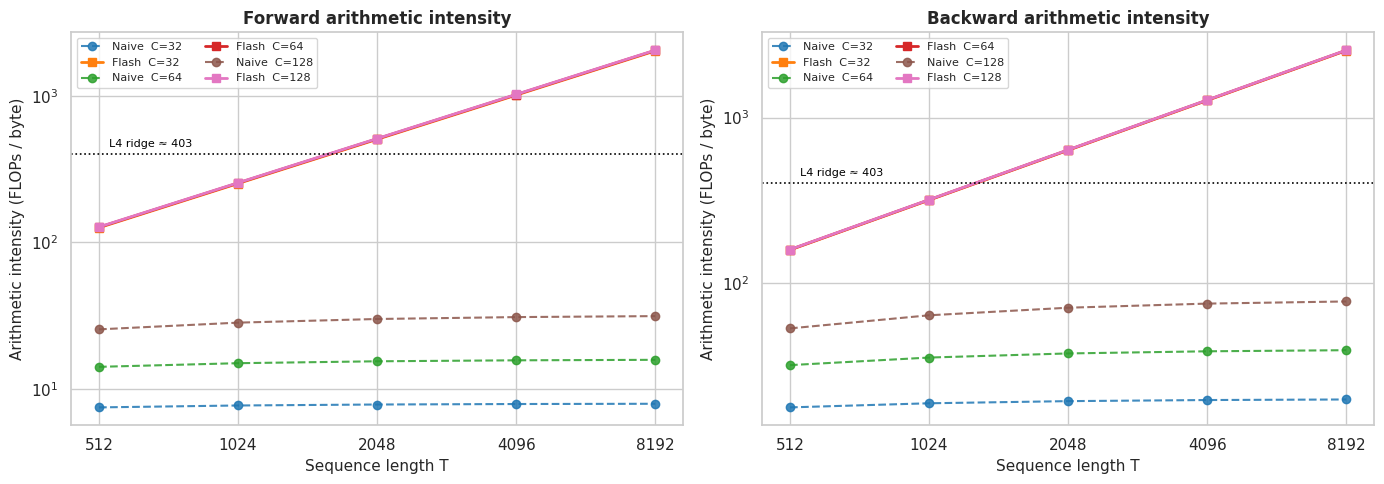

Saved: /content/drive/MyDrive/690AB/flash-attention/results/pallas_attn/pallas_arith_intensity.png

Key observation: Flash AI grows ∝ T (4 T C bytes in denominator); Naive AI plateaus (4 T² bytes dominates).


In [14]:
plot_dual_pass_lines(
    df, seq_col="T", seq_ticks=Ts, configs=Cs, config_col="C",
    naive_col_fmt="AI_naive_{direction}",
    flash_col_fmt="AI_flash_{direction}",
    naive_palette=naive_palette,
    flash_palette=flash_palette,
    ylabel="Arithmetic intensity (FLOPs / byte)",
    title_fmt="{direction} arithmetic intensity",
    output_path=os.path.join(RESULTS_DIR, "pallas_arith_intensity.png"),
    ridges=[
        (A100_RIDGE, "black", "A100 ridge"),
    ],
)
print(f"\nKey observation: Flash AI grows \u221d T (4 T C bytes in denominator); "
      f"Naive AI plateaus (4 T\u00b2 bytes dominates).")

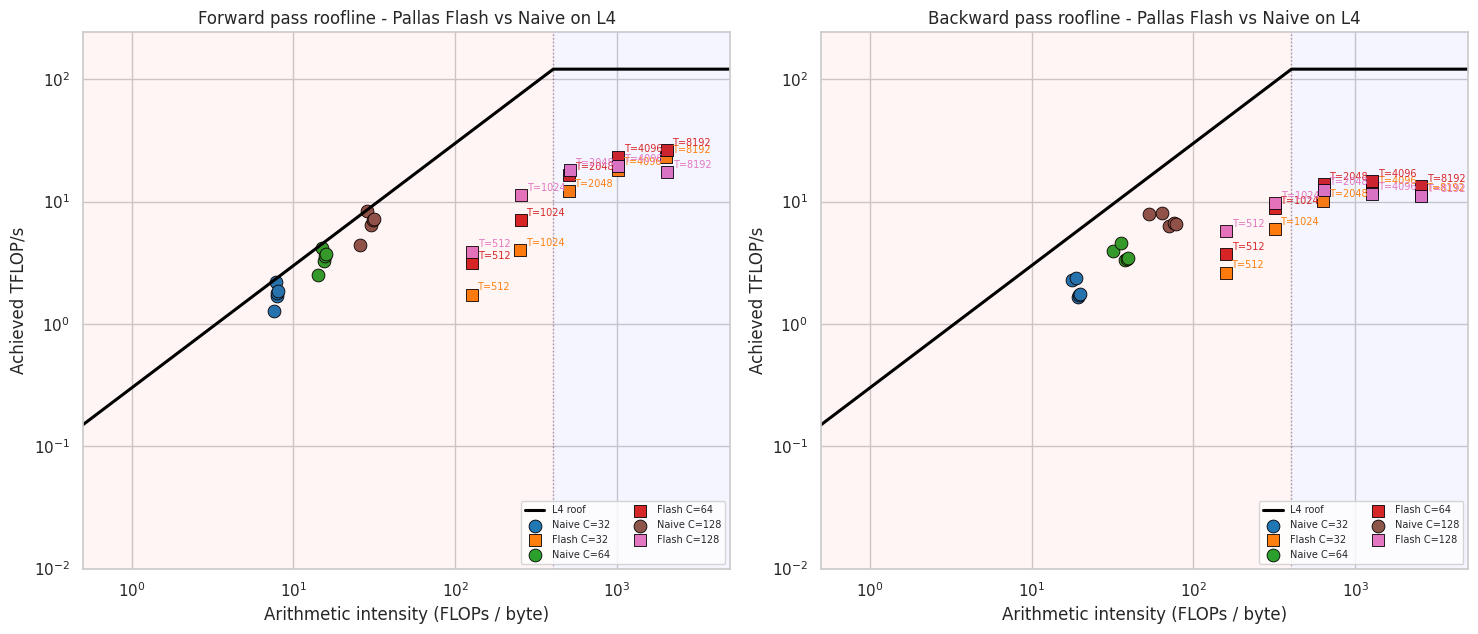

Saved: /content/drive/MyDrive/690AB/flash-attention/results/pallas_attn/pallas_roofline.png


In [15]:
plot_roofline_dual_pass(
    df=df,
    cs=Cs,
    peak_tflops=A100_PEAK_TFLOPS,
    peak_bw_gbs=A100_PEAK_BW_GBS,
    ridge_flops_per_byte=A100_RIDGE,
    naive_palette=naive_palette,
    flash_palette=flash_palette,
    output_path=os.path.join(RESULTS_DIR, "pallas_roofline.png"),
)